# Chapter 15 — Linear Image Filtering

Companion tutorial for **[Foundations of Computer Vision](https://visionbook.mit.edu/linear_image_filtering.html)** by Torralba, Isola, and Freeman (MIT Press, 2024).

Image filtering is the workhorse of low-level vision: blurring, sharpening, edge detection, and template matching are all the *same* operation — **convolution** of an image with a small kernel. This notebook reproduces the chapter's figures as runnable PyTorch / Kornia, building from continuous vs. discrete signals, through linear translation-invariant (LTI) systems and convolution, to cross-correlation and template matching.

**The thread through the chapter.** A *system* maps an input signal to an output. The special systems worth studying are **linear and translation-invariant** — and every LTI system is completely described by a single **impulse response** $h$, applied everywhere by convolution: $\ell_\text{out} = \ell_\text{in} * h$. Cross-correlation is the same computation without flipping the kernel, which is what template matching uses.

Where the book shows a photograph or hand sketch (e.g. the room-acoustics apparatus), it is referenced rather than reproduced; the filtering *operations* are reproduced on a stand-in image.

In [1]:
from pathlib import Path

import torch
import kornia
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})

# Locate the chapter's assets regardless of the working directory.
_CHAPTER_DIR = Path("notebooks/CV/mit-foundations/chapter-15-linear-image-filtering")
BASE_DIR = _CHAPTER_DIR if _CHAPTER_DIR.is_dir() else Path(".")
ASSETS_DIR = BASE_DIR / "assets"
print(f"torch {torch.__version__} on {DEVICE} | kornia {kornia.__version__}")

torch 2.12.1+cpu on cpu | kornia 0.8.3


In [2]:
# Shared palette — a consistent set of colours across the chapter's figures.
COLORS = {
    "dark":   "#111111",   # axes, primary lines, text
    "gray":   "#555555",   # secondary lines / text
    "blue":   "#1f6fe0",   # signals, rays
    "red":    "#c0392b",   # highlights, kernels, brackets
    "green":  "#3a8b3a",   # secondary highlight
    "cyan":   "#2997ff",   # reference lines
    "panel":  "#5f7695",   # panel labels "(a)", "(b)"
}

## 15.2 — Signals and Images

A one-dimensional **continuous** signal $\ell(t)$ is defined for every real $t$; sampling it on an integer grid gives the **discrete** signal $\ell[n]$. Images are just 2-D discrete signals $\ell[n,m]$.

**Figure 15.1 — a continuous signal and its discrete samples.**

> _Book §15.2, Figure 15.1 — computed here._

In [3]:
# Figure 15.1 — a continuous signal ℓ(t) and its discrete samples ℓ[n]. The discrete signal is
# the continuous one read off at the integers; here ℓ[n] = [3, 2, 1, 4] at n = 0..3 and zero
# elsewhere. A Catmull–Rom spline through those support points stands in for the continuous ℓ(t).
n = torch.arange(-3, 7)
ell = torch.zeros(10); ell[3:7] = torch.tensor([3.0, 2.0, 1.0, 4.0])   # samples at n = 0,1,2,3
cps = torch.tensor([[-2, 0], [-1, 0], [0, 3], [1, 2], [2, 1], [3, 4], [4, 0], [5, 0]], dtype=torch.float32)
u = torch.linspace(0, 1, 60).unsqueeze(1)
seg = lambda P0, P1, P2, P3: 0.5 * (2*P1 + (-P0+P2)*u + (2*P0-5*P1+4*P2-P3)*u**2 + (-P0+3*P1-3*P2+P3)*u**3)
curve = torch.cat([seg(cps[i-1], cps[i], cps[i+1], cps[i+2]) for i in range(1, len(cps) - 2)])
print(f"discrete samples ℓ[0..3] = {ell[3:7].tolist()}")

discrete samples ℓ[0..3] = [3.0, 2.0, 1.0, 4.0]


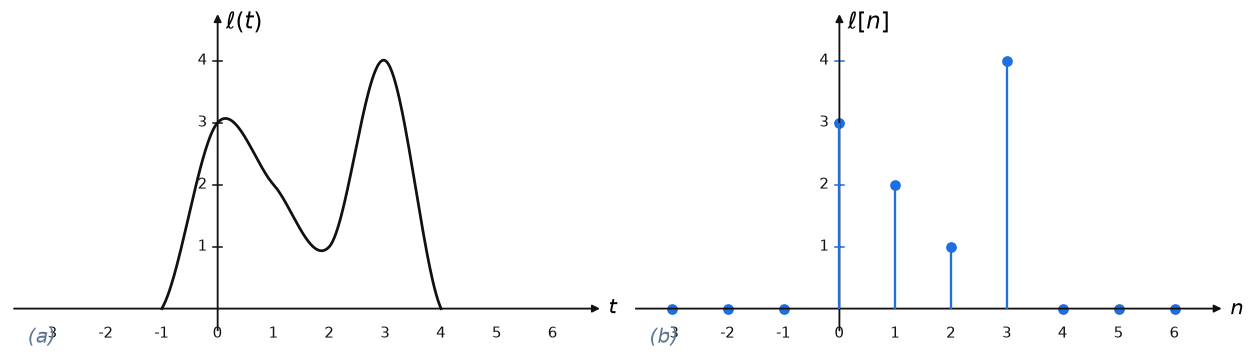

In [4]:
# Figure 15.1 — (a) the continuous curve ℓ(t); (b) its integer samples as a stem plot ℓ[n].
dark, blue = COLORS["dark"], COLORS["blue"]
def axes(ax, ylab):                                            # arrow-tipped x/y axes with integer ticks
    ax.axis("off"); ax.set(xlim=(-3.7, 6.9), ylim=(-0.7, 4.8))
    ax.annotate("", xy=(6.9, 0), xytext=(-3.7, 0), arrowprops=dict(arrowstyle="-|>", color=dark, lw=1.2))
    ax.annotate("", xy=(0, 4.8), xytext=(0, -0.4), arrowprops=dict(arrowstyle="-|>", color=dark, lw=1.2))
    for x in range(-3, 7): ax.text(x, -0.28, str(x), fontsize=10, ha="center", va="top", color=dark)
    for y in range(1, 5): ax.plot([-0.08, 0.08], [y, y], color=dark, lw=1.0); ax.text(-0.18, y, str(y), fontsize=10, ha="right", va="center", color=dark)
    ax.text(7.0, 0, {"c": "$t$", "d": "$n$"}[ylab[0]], fontsize=14, va="center")
    ax.text(0.15, 4.8, ylab[1], fontsize=15, ha="left", va="top")

fig, (axc, axd) = plt.subplots(1, 2, figsize=(11.5, 3.4))
axes(axc, ("c", r"$\ell(t)$")); axc.plot(curve[:, 0], curve[:, 1], color=dark, lw=1.8, zorder=3)
axc.text(-3.4, -0.55, "(a)", fontsize=13, color=COLORS["panel"], style="italic")
axes(axd, ("d", r"$\ell[n]$"))                                 # (b) discrete stem plot
axd.stem(n.tolist(), ell.tolist(), linefmt="-", markerfmt="o", basefmt=" ")
for line in axd.get_lines(): line.set_color(blue)
axd.collections[0].set_color(blue); axd.collections[0].set_zorder(4)
axd.text(-3.4, -0.55, "(b)", fontsize=13, color=COLORS["panel"], style="italic")
plt.tight_layout()
plt.show()

## 15.3 — Systems

A system $f$ maps an input signal to an output signal. The systems we care about are **linear** (they respect scaling and superposition) and **translation-invariant** (shifting the input just shifts the output).

**Figure 15.2 — a system maps an input signal to an output.**

> _Book §15.3, Figure 15.2 — drawn as a schematic._

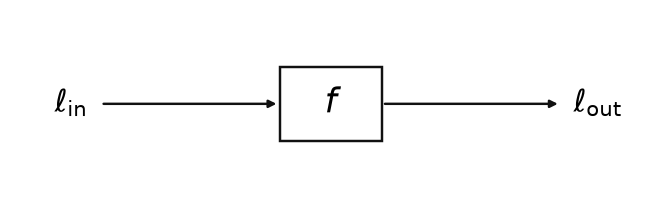

In [5]:
# Figure 15.2 — a system maps an input signal to an output signal. A block diagram: the input
# ℓ_in enters a system f and leaves as ℓ_out. The chapter studies which systems f are useful.
dark = COLORS["dark"]
fig, ax = plt.subplots(figsize=(7.5, 2.2)); ax.set(xlim=(0, 10), ylim=(0, 3)); ax.axis("off")
ax.add_patch(Rectangle((4.2, 0.9), 1.6, 1.2, fill=False, edgecolor=dark, lw=1.6))
ax.text(5.0, 1.5, r"$f$", fontsize=22, ha="center", va="center")
ax.annotate("", xy=(4.2, 1.5), xytext=(1.4, 1.5), arrowprops=dict(arrowstyle="-|>", color=dark, lw=1.6))
ax.annotate("", xy=(8.6, 1.5), xytext=(5.8, 1.5), arrowprops=dict(arrowstyle="-|>", color=dark, lw=1.6))
ax.text(1.2, 1.5, r"$\ell_{\mathrm{in}}$", fontsize=20, ha="right", va="center")
ax.text(8.8, 1.5, r"$\ell_{\mathrm{out}}$", fontsize=20, ha="left", va="center")
plt.show()

**Figure 15.3 — which of these image transforms are linear?.**

> _Book §15.3, Figure 15.3 — applied with Kornia._

In [6]:
# Figure 15.3 — apply four transforms to one image and ask which are LINEAR systems (respecting
# scaling and superposition of pixel values). rgb→gray (a fixed weighted channel sum) and defocus
# (a blur, i.e. a convolution) are linear; rotation and scaling remap pixel *locations* — linear
# maps but not translation-invariant, the distinction the chapter draws out.
from skimage.data import astronaut
img = torch.as_tensor(astronaut() / 255.0, dtype=torch.float32).permute(2, 0, 1)[None].to(DEVICE)  # (1,3,H,W)
rot = kornia.geometry.transform.rotate(img, torch.tensor([30.0], device=DEVICE))
small = kornia.geometry.transform.rescale(img, 0.5)                          # scale down, then re-centre on black
scal = torch.zeros_like(img); H, W = img.shape[-2:]; h, w = small.shape[-2:]
scal[..., (H - h) // 2:(H - h) // 2 + h, (W - w) // 2:(W - w) // 2 + w] = small
gray = kornia.color.rgb_to_grayscale(img).repeat(1, 3, 1, 1)                 # linear channel mix
blur = kornia.filters.gaussian_blur2d(img, (31, 31), (9.0, 9.0))            # defocus = convolution (linear)
print(f"image {tuple(img.shape[-2:])}; transforms: rotation, scaling, rgb2gray, defocus")

image (512, 512); transforms: rotation, scaling, rgb2gray, defocus


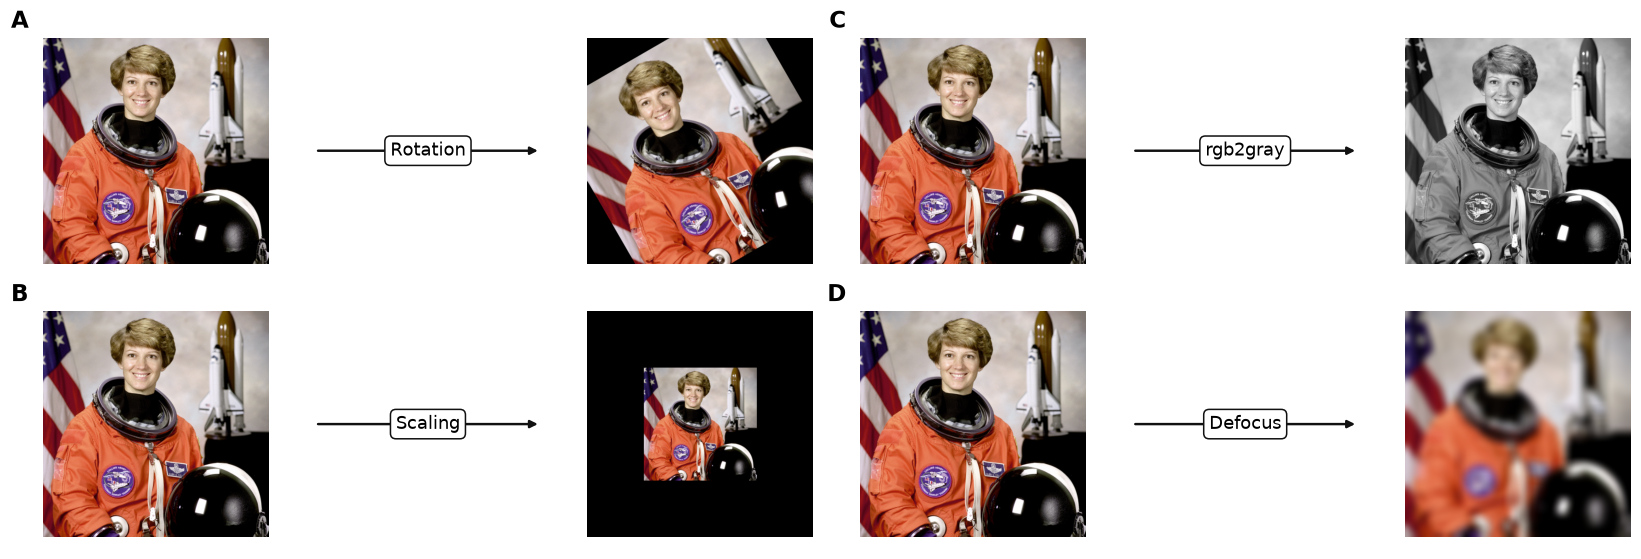

In [7]:
# Figure 15.3 — four input→[operation]→output triplets in a 2×2 layout. Grayscale and defocus
# are linear systems; rotation and scaling are not translation-invariant.
dark = COLORS["dark"]
show = lambda ax, im: (ax.imshow(im[0].permute(1, 2, 0).cpu().clamp(0, 1)), ax.axis("off"))
ops = [("A", "Rotation", rot), ("C", "rgb2gray", gray), ("B", "Scaling", scal), ("D", "Defocus", blur)]
fig, axes = plt.subplots(2, 6, figsize=(15, 5.2))
for k, (tag, name, out) in enumerate(ops):
    r, c = k // 2, (k % 2) * 3
    show(axes[r, c], img)                                                    # input
    op = axes[r, c + 1]; op.axis("off"); op.set(xlim=(0, 1), ylim=(0, 1))    # [operation] box + arrow
    op.annotate("", xy=(1.0, 0.5), xytext=(0.0, 0.5), arrowprops=dict(arrowstyle="-|>", color=dark, lw=1.6))
    op.text(0.5, 0.5, name, fontsize=12, ha="center", va="center", bbox=dict(boxstyle="round", fc="white", ec=dark))
    show(axes[r, c + 2], out)                                                # output
    axes[r, c].text(-0.06, 1.02, tag, transform=axes[r, c].transAxes, fontsize=15, fontweight="bold", va="bottom", ha="right")
plt.tight_layout()
plt.show()

**Figure 15.4 — dense vs. local connectivity.** A general linear filter is a matrix multiply $y = Hx$ in which every output pixel depends on every input pixel (a *fully-connected* layer). **Convolution restricts $H$ to local connections** — each output uses only a small window of nearby inputs — which is what makes filtering practical. *(Book §15.3.1, Figure 15.4 — computed here.)*

In [8]:
# Figure 15.4 — the same linear system y = H·x, two ways. A DENSE operator lets output pixel 5
# depend on every input pixel (row 5 of H is all-nonzero). A CONVOLUTION restricts H to a local
# band — output 5 depends only on a small window — which is why convolution is practical.
N = 11
H_dense = torch.randn(N, N)                       # dense: row 5 touches all inputs
k = torch.tensor([0.25, 0.5, 0.25])               # 3-tap kernel
H_conv = torch.zeros(N, N)                         # convolution: banded (each row = shifted kernel)
for i in range(N):
    for j, w in zip((i - 1, i, i + 1), k):
        if 0 <= j < N: H_conv[i, j] = w
print(f"output pixel 5 depends on {int((H_dense[5] != 0).sum())} inputs (dense) "
      f"vs {int((H_conv[5] != 0).sum())} inputs (convolution)")

output pixel 5 depends on 11 inputs (dense) vs 3 inputs (convolution)


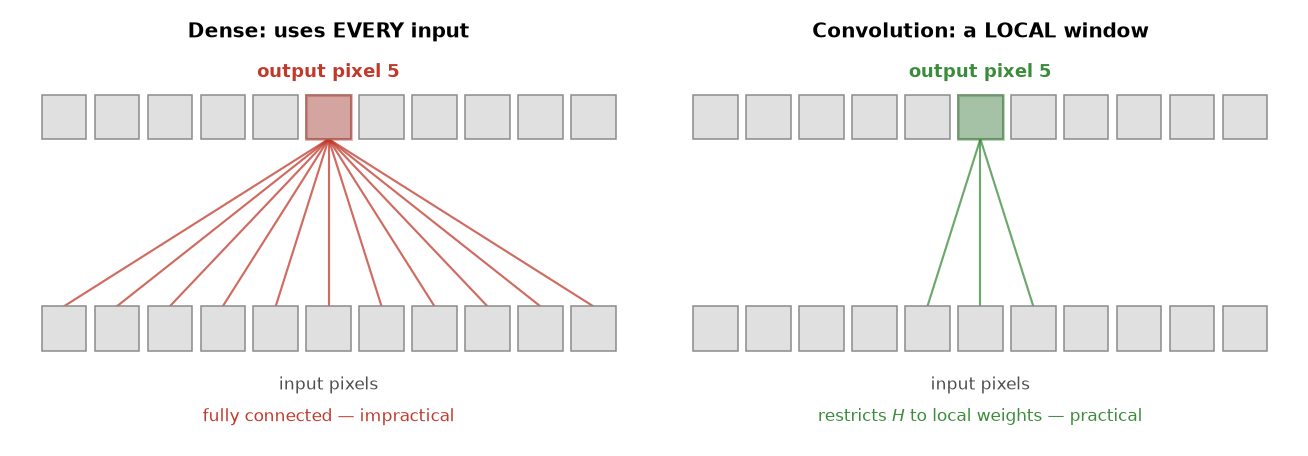

In [9]:
# Figure 15.4 — output pixel 5 (top) linked to the input pixels (bottom) it is built from. Left:
# dense H — a line to EVERY input. Right: convolution — only a local window. Same picture, and the
# only difference is which weights of H are allowed to be nonzero.
red, green = COLORS["red"], COLORS["green"]
def panel(ax, row, col, title, tag):
    for j in range(N):                                              # input row (bottom) + output row (top)
        ax.add_patch(Rectangle((j - 0.42, -0.42), 0.84, 0.84, fc="0.88", ec="0.55", lw=1))
        ax.add_patch(Rectangle((j - 0.42, 3.58), 0.84, 0.84, fc="0.88", ec="0.55", lw=1))
    ax.add_patch(Rectangle((5 - 0.42, 3.58), 0.84, 0.84, fc=col, ec=col, alpha=0.35, lw=2))   # output pixel 5
    for j in range(N):                                             # lines: output 5 -> each input it uses
        if row[j] != 0: ax.plot([5, j], [3.58, 0.42], color=col, lw=1.4, alpha=0.75, zorder=0)
    ax.text(5, 4.75, "output pixel 5", color=col, fontsize=12, ha="center", fontweight="bold")
    ax.text((N - 1) / 2, -1.15, "input pixels", color="0.3", fontsize=11, ha="center")
    ax.text((N - 1) / 2, 5.5, title, fontsize=13, ha="center", fontweight="bold")
    ax.text((N - 1) / 2, -1.75, tag, fontsize=11, ha="center", color=col)
    ax.set(xlim=(-1, N), ylim=(-2.2, 6.0)); ax.set_aspect("equal"); ax.axis("off")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.6))
panel(axL, H_dense[5], red, "Dense: uses EVERY input", "fully connected — impractical")
panel(axR, H_conv[5], green, "Convolution: a LOCAL window", "restricts $H$ to local weights — practical")
plt.tight_layout()
plt.show()

## 15.4 — Convolution

An LTI system applies one **impulse response** $h$ at every position: the output is the input **convolved** with $h$. Convolution flips the kernel and slides it; it is linear, translation-invariant, commutative and associative.

**Figure 15.5 — translation invariance.** A bird looks the same wherever it appears in the sky, so a useful filter must respond identically at every position: shifting the input just shifts the output, $f(\text{shift}(x)) = \text{shift}(f(x))$. *(Book §15.3.2, Figure 15.5 — the birds photo, filtered here.)*

In [10]:
# Figure 15.5 — translation invariance. A bird looks the same wherever it is in the sky, so a
# useful filter must respond the same way at every position — shifting the input just shifts the
# output. We blur the birds photo, then blur a shifted copy; the second is the first shifted by the
# same amount, f(shift(x)) = shift(f(x)) — verified below on the interior.
import torch.nn.functional as F
birds = torch.as_tensor(plt.imread(ASSETS_DIR / "birds.jpg")[..., :3] / 255.0, dtype=torch.float32).permute(2, 0, 1)[None]
x = F.interpolate(birds, scale_factor=0.42, mode="area").to(DEVICE)     # ~500 px wide
shift = (0, 190)                                              # (dy, dx) pixels
xs = torch.roll(x, shifts=shift, dims=(-2, -1))
blur = lambda im: kornia.filters.gaussian_blur2d(im, (21, 21), (6.0, 6.0), border_type="circular")
y, ys = blur(x), blur(xs)
resid = (ys - torch.roll(y, shift, (-2, -1)))[..., 12:-12, 12:-12].abs().max()
print(f"birds {tuple(x.shape[-2:])}; shift {shift}px; interior |f(shift x) - shift f(x)| = {resid:.1e}  (translation invariant)")

birds (338, 503); shift (0, 190)px; interior |f(shift x) - shift f(x)| = 0.0e+00  (translation invariant)


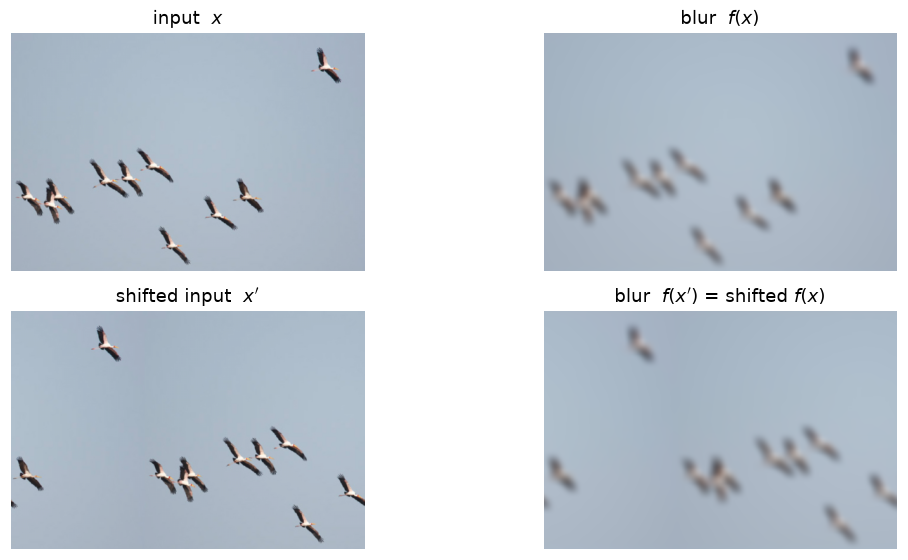

In [11]:
# Figure 15.5 — top: the birds and their blur; bottom: the shifted birds and their blur. The bottom
# output is the top output shifted by the same vector — the hallmark of a translation-invariant system.
show = lambda ax, im, t: (ax.imshow(im[0].permute(1, 2, 0).cpu().clamp(0, 1)), ax.axis("off"), ax.set_title(t, fontsize=12))
fig, axes = plt.subplots(2, 2, figsize=(11, 5.2))
show(axes[0, 0], x, r"input  $x$"); show(axes[0, 1], y, r"blur  $f(x)$")
show(axes[1, 0], xs, r"shifted input  $x'$"); show(axes[1, 1], ys, r"blur  $f(x')$ = shifted $f(x)$")
plt.tight_layout()
plt.show()

**Figure 15.6 — convolution is weight sharing.** Where 15.4's dense operator wires each output to *every* input, a convolution wires each output to a small local window using the **same kernel weights at every position**. That one shared, shifted kernel is exactly what a banded Toeplitz matrix encodes, and it is what makes the filter translation-invariant. *(Book §15.4, Figure 15.6 — computed here.)*

In [12]:
# Figure 15.6 — a convolution is a linear system whose operator H shares ONE small kernel across
# every output: row k uses the same weights h = [h[-1], h[0], h[1]] as every other row, just shifted.
# That weight sharing — the same kernel everywhere — is what makes convolution translation-invariant.
N = 11
h = torch.tensor([0.25, 0.5, 0.25])               # the shared 3-tap kernel: h[-1], h[0], h[1]
H = torch.zeros(N, N)
for i in range(N):                                # each output row = the same kernel, shifted
    for j, w in zip((i - 1, i, i + 1), h):
        if 0 <= j < N: H[i, j] = w
print(f"one shared kernel {h.tolist()} -> {int((H != 0).sum())} nonzeros in {N}x{N} H (a narrow band)")

one shared kernel [0.25, 0.5, 0.25] -> 31 nonzeros in 11x11 H (a narrow band)


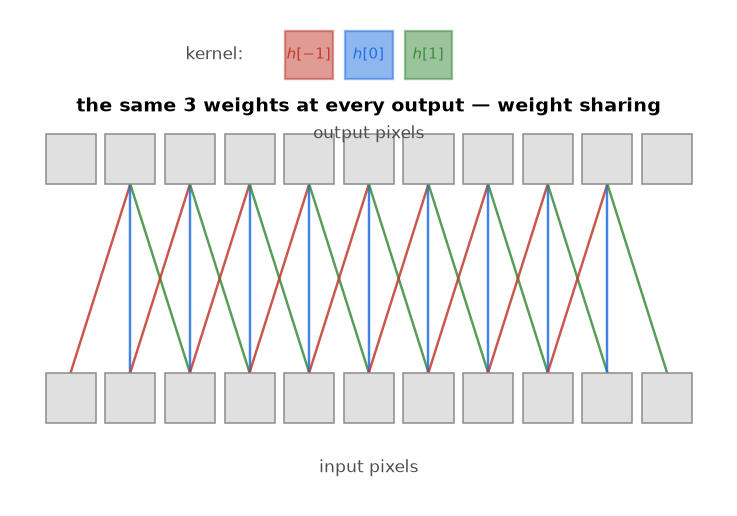

In [13]:
# Figure 15.6 — every output pixel is wired to its three local inputs, and the three connection
# colours (kernel taps h[-1], h[0], h[1]) repeat identically at each output: one kernel slid across.
# That shared, shifted pattern IS convolution (contrast 15.4's dense fan into a single output).
taps = [(-1, COLORS["red"], "$h[-1]$"), (0, COLORS["blue"], "$h[0]$"), (1, COLORS["green"], "$h[1]$")]
fig, ax = plt.subplots(figsize=(11, 4.8))
for j in range(N):
    ax.add_patch(Rectangle((j - 0.42, -0.42), 0.84, 0.84, fc="0.88", ec="0.55", lw=1))     # input row
    ax.add_patch(Rectangle((j - 0.42, 3.58), 0.84, 0.84, fc="0.88", ec="0.55", lw=1))      # output row
for o in range(1, N - 1):                          # each output pixel -> its 3 local inputs
    for off, col, _ in taps:
        ax.plot([o, o + off], [3.58, 0.42], color=col, lw=1.6, alpha=0.85, zorder=0)
for i, (off, col, lab) in enumerate(taps):         # kernel legend
    ax.add_patch(Rectangle((3.6 + i, 5.35), 0.8, 0.8, fc=col, ec=col, alpha=0.5, lw=1.5))
    ax.text(4.0 + i, 5.75, lab, ha="center", va="center", fontsize=10, color=col)
ax.text(2.9, 5.75, "kernel:", ha="right", va="center", fontsize=11, color="0.3")
ax.text((N - 1) / 2, 4.8, "the same 3 weights at every output — weight sharing", ha="center", fontsize=12.5, fontweight="bold")
ax.text((N - 1) / 2, -1.25, "input pixels", ha="center", fontsize=11, color="0.3")
ax.text((N - 1) / 2, 4.35, "output pixels", ha="center", fontsize=11, color="0.3")
ax.set(xlim=(-1, N), ylim=(-1.8, 6.5)); ax.set_aspect("equal"); ax.axis("off")
plt.tight_layout()
plt.show()

**Figure 15.7 — 2-D convolution of a 9×9 image with a 3×3 kernel, step by step.**

> _Book §15.4, Figure 15.7 — computed here._

In [14]:
# Figure 15.7 — 2-D convolution, step by step. The input ℓ_in is a 9×9 binary disc indexed by
# (n, m); the kernel h is a 3×3 edge filter centred at the origin (n, m ∈ {−1,0,1}). Convolution
# FLIPS the kernel (h[−n,−m]) and slides it: each output pixel is the sum of the flipped kernel
# times the overlapping input patch. Flat regions of the input give exactly 0 in the output.
import torch.nn.functional as F
mm, nn = torch.meshgrid(torch.arange(9.0), torch.arange(9.0), indexing="ij")
Lin = ((nn - 4) ** 2 + (mm - 4) ** 2 <= 2.6 ** 2).float()      # 9×9 disc of ones
h = torch.tensor([[1.0, 0.0, -1.0], [1.0, 0.0, -1.0], [1.0, 0.0, -1.0]])   # vertical-edge kernel (book: 1 at n=-1, -1 at n=1)
h_flip = torch.flip(h, dims=(0, 1))                            # h[−n,−m]
Lout = F.conv2d(Lin[None, None], h_flip[None, None], padding=1)[0, 0]      # ℓ_out = ℓ_in * h
print(f"ℓ_in disc: {int(Lin.sum())} ones; ℓ_out range [{Lout.min():.0f}, {Lout.max():.0f}]; zeros: {int((Lout==0).sum())}")

ℓ_in disc: 21 ones; ℓ_out range [-3, 3]; zeros: 45


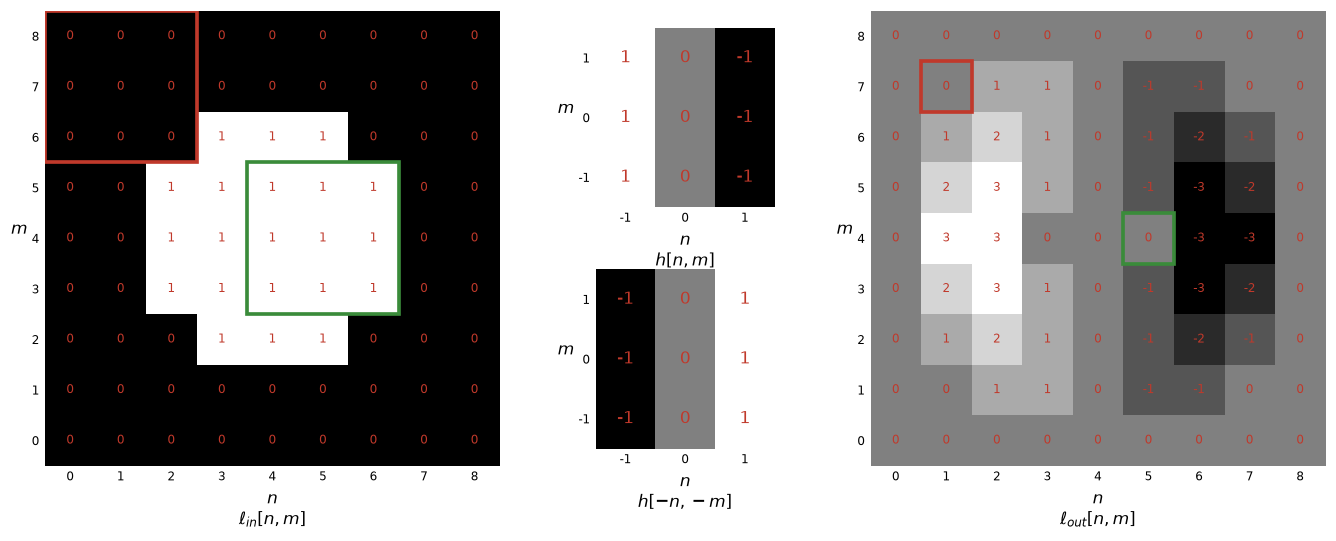

In [15]:
# Figure 15.7 — input, kernel h and its flip h[−n,−m], and output. Every cell shows its value in
# red (so the 0s stand out); each grid carries its (n, m) axes with the origin at (0,0).
red = COLORS["red"]
def grid(ax, M, nlab, mlab, title, fs=8):
    ax.imshow(M, cmap="gray", origin="lower", vmin=float(M.min()), vmax=float(M.max()))
    for mi in range(M.shape[0]):
        for ni in range(M.shape[1]):
            ax.text(ni, mi, f"{M[mi, ni]:g}", color=red, ha="center", va="center", fontsize=fs)
    ax.set_xticks(range(len(nlab))); ax.set_xticklabels(nlab, fontsize=8)
    ax.set_yticks(range(len(mlab))); ax.set_yticklabels(mlab, fontsize=8)
    ax.set_xlabel(f"$n$\n{title}", fontsize=11); ax.set_ylabel("$m$", fontsize=11, rotation=0, labelpad=8)
    for s in ax.spines.values(): s.set_visible(False)
    ax.tick_params(length=0)
K = ["-1", "0", "1"]; G = [str(i) for i in range(9)]

fig = plt.figure(figsize=(13, 5))
gs = fig.add_gridspec(2, 3, width_ratios=[9, 3, 9], height_ratios=[1, 1])
axL = fig.add_subplot(gs[:, 0]); axO = fig.add_subplot(gs[:, 2])
axh = fig.add_subplot(gs[0, 1]); axf = fig.add_subplot(gs[1, 1])
grid(axL, Lin, G, G, r"$\ell_{in}[n,m]$")
grid(axO, Lout, G, G, r"$\ell_{out}[n,m]$")
grid(axh, h, K, K, r"$h[n,m]$", fs=11)
grid(axf, h_flip, K, K, r"$h[-n,-m]$", fs=11)
for ax, r, c, col in [(axL, 6, 0, red), (axL, 3, 4, COLORS["green"])]:      # kernel placements on the input
    ax.add_patch(Rectangle((c - 0.5, r - 0.5), 3, 3, fill=False, edgecolor=col, lw=2.4))
for ax, r, c, col in [(axO, 7, 1, red), (axO, 4, 5, COLORS["green"])]:      # the output pixels they produce
    ax.add_patch(Rectangle((c - 0.5, r - 0.5), 1, 1, fill=False, edgecolor=col, lw=2.4))
plt.tight_layout()
plt.show()

**Figure 15.8 — defocus is a convolution; rotation is not.**

> _Book §15.4.2, Figure 15.8 — applied with Kornia._

In [16]:
# Figure 15.8 — is the transform a convolution? Defocus applies the SAME blur kernel at every
# position (translation-invariant → a convolution). Rotation sends a patch to a position that
# depends on where it started (not translation-invariant → not a convolution). We mark two patches
# and track where they land: unchanged locations under defocus, rotated locations under rotation.
import math
from skimage.data import astronaut
img = torch.as_tensor(astronaut() / 255.0, dtype=torch.float32).permute(2, 0, 1)[None].to(DEVICE)
blur = kornia.filters.gaussian_blur2d(img, (41, 41), (12.0, 12.0))
angle = 35.0
rot = kornia.geometry.transform.rotate(img, torch.tensor([angle], device=DEVICE))
H, W = img.shape[-2:]; cx, cy = (W - 1) / 2, (H - 1) / 2; th = math.radians(angle)
patches = [(150, 160), (360, 330)]                            # (row, col) patch centres on the input
rot_patches = [(math.sin(th) * (c - cx) + math.cos(th) * (r - cy) + cy,      # where each patch lands after rotation
                math.cos(th) * (c - cx) - math.sin(th) * (r - cy) + cx) for r, c in patches]
print(f"image {H}x{W}; defocus keeps patch locations; rotation moves them by {angle}°")

image 512x512; defocus keeps patch locations; rotation moves them by 35.0°


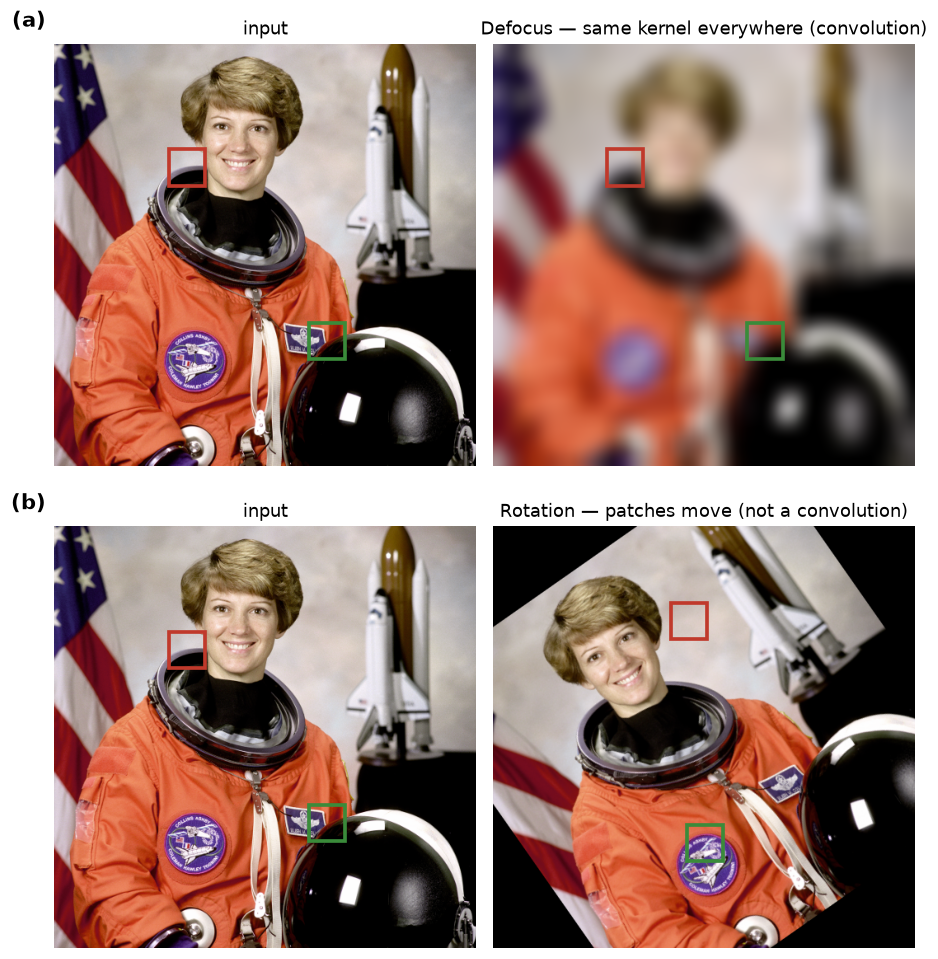

In [17]:
# Figure 15.8 — (a) defocus: same patches, same locations in input and output (a convolution).
# (b) rotation: the same patches land at rotated, position-dependent locations (not a convolution).
red, green = COLORS["red"], COLORS["green"]
show = lambda ax, im, t: (ax.imshow(im[0].permute(1, 2, 0).cpu().clamp(0, 1)), ax.axis("off"), ax.set_title(t, fontsize=12))
box = lambda ax, rc, col: ax.add_patch(Rectangle((rc[1] - 22, rc[0] - 22), 44, 44, fill=False, edgecolor=col, lw=2.4))
fig, axes = plt.subplots(2, 2, figsize=(8.5, 9))
show(axes[0, 0], img, "input"); show(axes[0, 1], blur, "Defocus — same kernel everywhere (convolution)")
show(axes[1, 0], img, "input"); show(axes[1, 1], rot, "Rotation — patches move (not a convolution)")
for (rc, col) in zip(patches, (red, green)):
    box(axes[0, 0], rc, col); box(axes[0, 1], rc, col); box(axes[1, 0], rc, col)          # defocus: same location
for (rc, col) in zip(rot_patches, (red, green)):
    box(axes[1, 1], rc, col)                                                              # rotation: moved location
axes[0, 0].text(-0.02, 1.04, "(a)", transform=axes[0, 0].transAxes, fontsize=14, fontweight="bold", ha="right")
axes[1, 0].text(-0.02, 1.04, "(b)", transform=axes[1, 0].transAxes, fontsize=14, fontweight="bold", ha="right")
plt.tight_layout()
plt.show()

**Figure 15.9 — four convolutions: identity, shift, superposition, averaging.**

> _Book §15.4.2, Figure 15.9 — applied with Kornia._

In [18]:
# Figure 15.9 — four convolutions of one image, each set by a 5×5 kernel whose values are shown.
# A single 1 at the centre is the identity; an off-centre 1 shifts the image; two 0.5's superpose
# the image with a shifted copy; a flat 1/25 box averages a neighbourhood (blur). (A small image is
# used so the small kernel's shift is visible.)
import torch.nn.functional as F
from skimage.data import astronaut
img = torch.as_tensor(astronaut() / 255.0, dtype=torch.float32).permute(2, 0, 1)[None].to(DEVICE)
img = F.interpolate(img, size=(96, 96), mode="area")
K = torch.zeros(4, 5, 5)
K[0, 2, 2] = 1.0                                   # identity
K[1, 2, 4] = 1.0                                   # shift (one step right, per the book)
K[2, 0, 0] = 0.5; K[2, 4, 4] = 0.5                 # superposition (two opposite corners, per the book)
K[3] = torch.ones(5, 5) / 25.0                     # 5×5 box average
outs = [kornia.filters.filter2d(img, k[None].to(DEVICE), border_type="replicate") for k in K]
print("kernels: identity, shift, superposition, 1/25 box — values shown on each 5x5 grid")

kernels: identity, shift, superposition, 1/25 box — values shown on each 5x5 grid


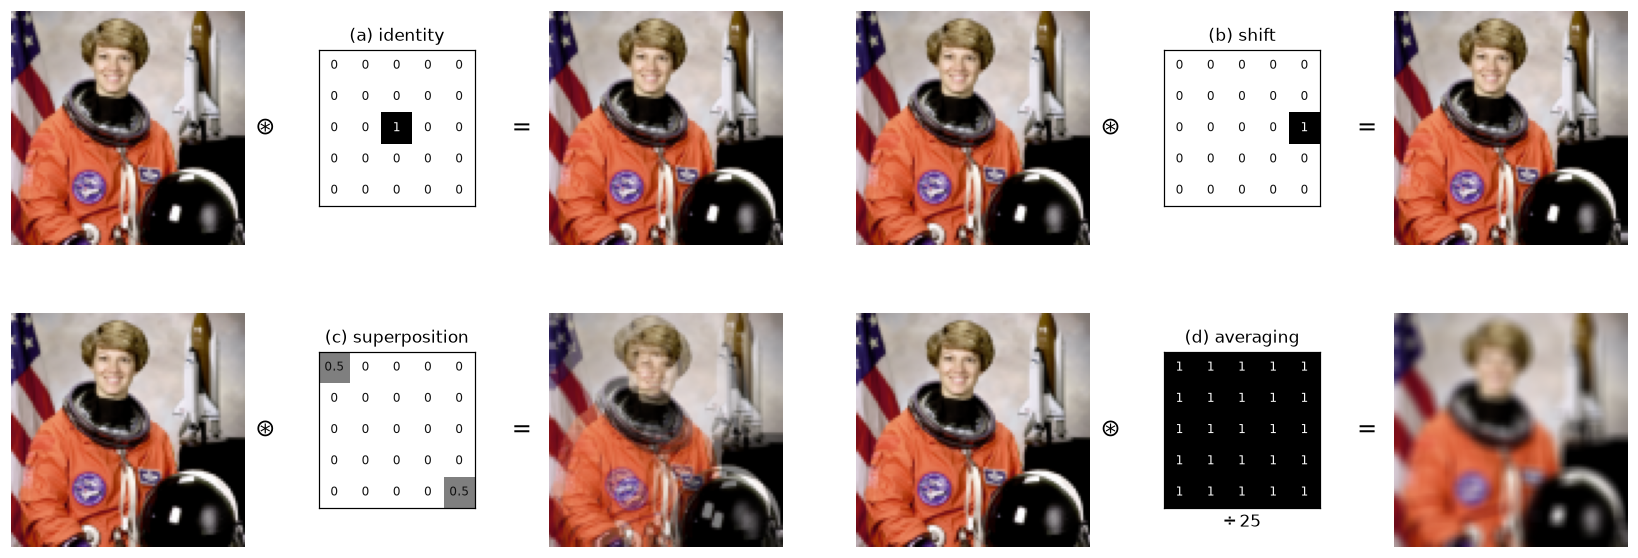

In [19]:
# Figure 15.9 — each cell: input  ⊛  kernel (5×5, values shown)  =  output.
dark = COLORS["dark"]
show = lambda ax, im: (ax.imshow(im[0].permute(1, 2, 0).cpu().clamp(0, 1)), ax.axis("off"))
def kgrid(ax, Kd, fmt, note=""):
    ax.imshow(Kd, cmap="gray_r", vmin=0, vmax=1); ax.set_xticks([]); ax.set_yticks([])
    for i in range(5):
        for j in range(5):
            tc = "white" if Kd[i, j].item() > 0.5 else dark
            ax.text(j, i, fmt(Kd[i, j].item()), ha="center", va="center", fontsize=8, color=tc)
    if note: ax.set_xlabel(note, fontsize=11)
panels = [("(a) identity", K[0], K[0], lambda v: f"{v:g}", ""),
          ("(b) shift", K[1], K[1], lambda v: f"{v:g}", ""),
          ("(c) superposition", K[2], K[2], lambda v: f"{v:g}", ""),
          ("(d) averaging", K[3], torch.ones(5, 5), lambda v: "1", r"$\div\,25$")]
fig, axes = plt.subplots(2, 6, figsize=(15, 5.8), gridspec_kw={"width_ratios": [3, 2, 3, 3, 2, 3]})
for p, (name, _, Kd, fmt, note) in enumerate(panels):
    r, c = p // 2, (p % 2) * 3
    show(axes[r, c], img); kgrid(axes[r, c + 1], Kd, fmt, note); show(axes[r, c + 2], outs[p])
    axes[r, c + 1].set_title(name, fontsize=11)
    axes[r, c + 1].text(-0.34, 0.5, r"$\circledast$", transform=axes[r, c + 1].transAxes, fontsize=16, va="center", ha="center")
    axes[r, c + 1].text(1.30, 0.5, "=", transform=axes[r, c + 1].transAxes, fontsize=16, va="center", ha="center")
plt.tight_layout()
plt.show()

**Figure 15.10 — handling boundaries: zero, circular, mirror and replicate padding.**

> _Book §15.4.3, Figure 15.10 — applied with Kornia._

In [20]:
# Figure 15.10 — a kernel needs pixels beyond the image edge. Four ways to invent them — zero,
# circular wrap, mirror, and edge-replicate padding — give different results near the border. We
# crop an inner window (so the true surround is known), blur it under each padding, and compare to
# the ground-truth blur that uses the real neighbouring pixels.
import torch.nn.functional as F
big = torch.as_tensor(plt.imread(ASSETS_DIR / "zebra.jpg")[..., :3] / 255.0, dtype=torch.float32).permute(2, 0, 1)[None].to(DEVICE)
a, b, pad, ks, sig = 150, 650, 44, 41, 10.0                     # inner window, pad width, blur kernel/sigma
inner = big[..., a:b, a:b]
gt = kornia.filters.gaussian_blur2d(big, (ks, ks), (sig, sig))[..., a:b, a:b]   # blur using REAL neighbours
modes = [("zero padding", "constant"), ("circular repetition", "circular"),
         ("mirror edge pixels", "reflect"), ("repeat edge pixels", "replicate")]
padded = [F.pad(inner, (pad,) * 4, mode=("constant" if m == "constant" else m)) for _, m in modes]
blurred = [kornia.filters.gaussian_blur2d(inner, (ks, ks), (sig, sig), border_type=m) for _, m in modes]
errs = [(o - gt).abs().mean(1, keepdim=True) for o in blurred]
print(f"inner {inner.shape[-1]}px; boundary error (mean abs) per mode: " +
      ", ".join(f"{n.split()[0]}={e.mean():.3f}" for (n, _), e in zip(modes, errs)))

inner 500px; boundary error (mean abs) per mode: zero=0.017, circular=0.003, mirror=0.001, repeat=0.001


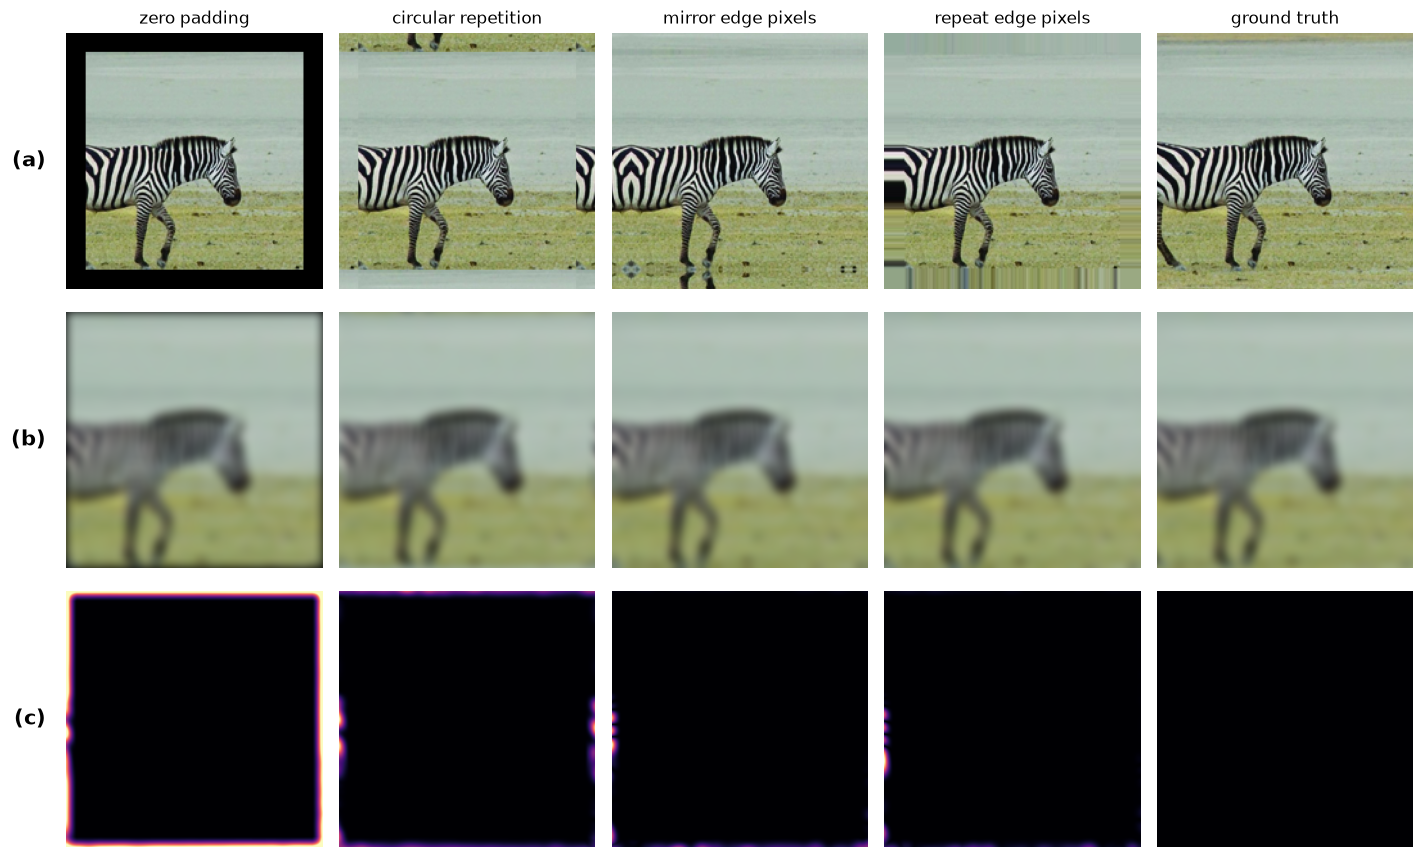

In [21]:
# Figure 15.10 — rows: (a) how each padding extends the border, (b) the blurred result, (c) the
# boundary error vs ground truth (brighter = larger). The last column is the true-context reference.
show = lambda ax, im: (ax.imshow(im[0].permute(1, 2, 0).cpu().clamp(0, 1)), ax.axis("off"))
gt_pad = big[..., a - pad:b + pad, a - pad:b + pad]
fig, axes = plt.subplots(3, 5, figsize=(13, 8))
for j, ((name, _), pim, bim, e) in enumerate(zip(modes, padded, blurred, errs)):
    show(axes[0, j], pim); axes[0, j].set_title(name, fontsize=11)
    show(axes[1, j], bim)
    axes[2, j].imshow((e[0, 0] * 4).clamp(0, 1).cpu(), cmap="magma"); axes[2, j].axis("off")
show(axes[0, 4], gt_pad); axes[0, 4].set_title("ground truth", fontsize=11)
show(axes[1, 4], gt); axes[2, 4].imshow(torch.zeros_like(errs[0][0, 0]).cpu(), cmap="magma", vmin=0, vmax=1); axes[2, 4].axis("off")
for r, lab in enumerate(["(a)", "(b)", "(c)"]):
    axes[r, 0].text(-0.08, 0.5, lab, transform=axes[r, 0].transAxes, fontsize=14, fontweight="bold", va="center", ha="right")
plt.tight_layout()
plt.show()

## 15.5 — Cross-Correlation vs. Convolution

Cross-correlation is convolution **without** flipping the kernel. For template matching we slide a template over the image and measure similarity; **normalized** cross-correlation removes the effect of local brightness.

**Figure 15.11 — cross-correlation vs. convolution (kernel orientation).**

> _Book §15.5, Figure 15.11 — computed here._

In [22]:
# Figure 15.11 — cross-correlation is convolution WITHOUT flipping the kernel. With an asymmetric
# triangle kernel, convolving an impulse image reproduces the kernel upright, while correlating it
# reproduces the kernel flipped (pointing down). On real shapes, correlation is the matched filter:
# it peaks where the image looks like the (unflipped) kernel.
import torch.nn.functional as F
def triangle(S, up=True):                                     # filled triangle, apex up or down
    t = torch.zeros(S, S)
    for i in range(S):
        w = int((i if up else S - 1 - i) * 0.5)
        t[i, S // 2 - w:S // 2 + w + 1] = 1.0
    return t
K = triangle(15, up=True)                                     # asymmetric kernel (top ≠ bottom)
impulses = torch.zeros(1, 1, 90, 90)
for (r, c, a) in [(20, 20, 1.0), (26, 62, 0.55), (58, 33, 0.8), (68, 70, 0.65)]: impulses[0, 0, r, c] = a
shapes = torch.zeros(1, 1, 90, 90)                            # a few up/down triangles in the scene
for (r, c, up) in [(14, 16, True), (18, 55, False), (52, 36, True)]:
    shapes[0, 0, r:r + 15, c:c + 15] = triangle(15, up)
conv = lambda x: F.conv2d(x, torch.flip(K, (0, 1))[None, None], padding=7)   # convolution flips the kernel
corr = lambda x: F.conv2d(x, K[None, None], padding=7)                       # cross-correlation does not
print(f"kernel 15×15 up-triangle; convolution keeps it upright, correlation flips it")

kernel 15×15 up-triangle; convolution keeps it upright, correlation flips it


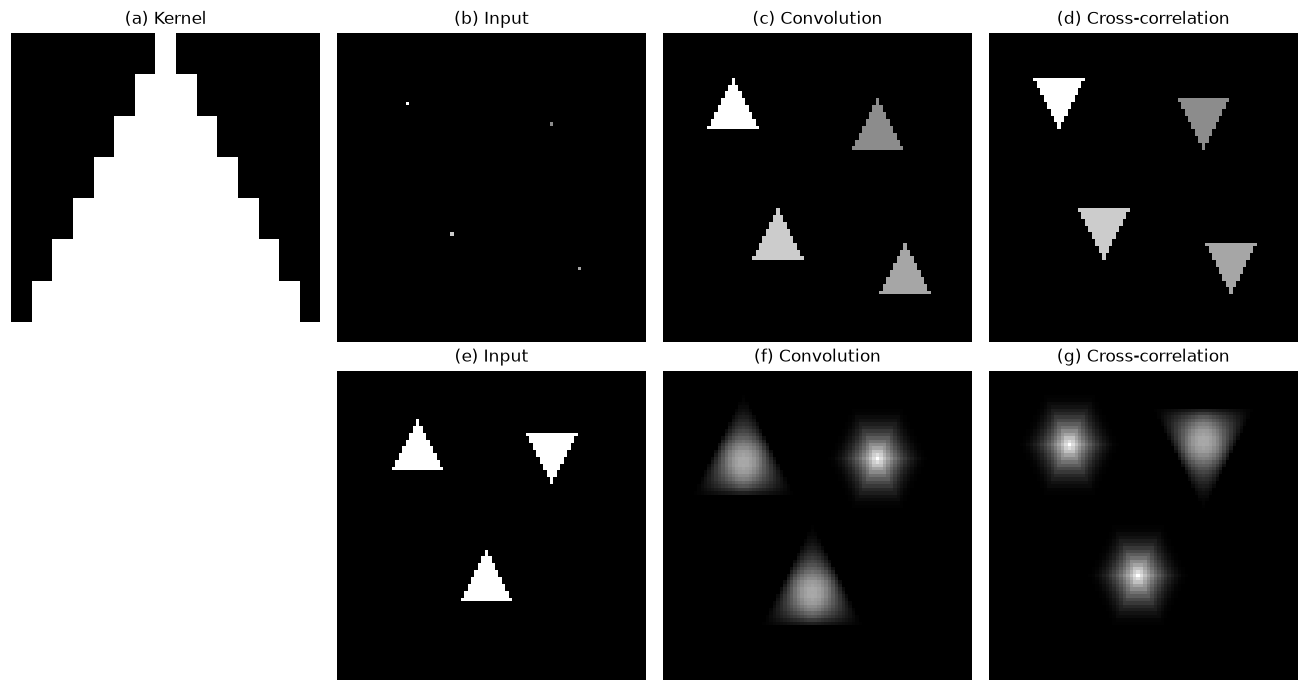

In [23]:
# Figure 15.11 — (a) kernel; top row: impulses, their convolution (upright), their correlation
# (flipped); bottom row: shapes, convolution, correlation (peaks on the matching up-triangles).
imsh = lambda ax, im, t: (ax.imshow(im.squeeze().cpu(), cmap="gray"), ax.axis("off"), ax.set_title(t, fontsize=11))
fig, axes = plt.subplots(2, 4, figsize=(12, 6.4))
imsh(axes[0, 0], K, "(a) Kernel")
imsh(axes[0, 1], impulses, "(b) Input"); imsh(axes[0, 2], conv(impulses), "(c) Convolution"); imsh(axes[0, 3], corr(impulses), "(d) Cross-correlation")
axes[1, 0].axis("off")
imsh(axes[1, 1], shapes, "(e) Input"); imsh(axes[1, 2], conv(shapes), "(f) Convolution"); imsh(axes[1, 3], corr(shapes), "(g) Cross-correlation")
plt.tight_layout()
plt.show()

**Figure 15.12 — template matching for the letter “a” via normalized cross-correlation.**

> _Book §15.5.1, Figure 15.12 — computed here._

In [24]:
# Figure 15.12 — template matching. We slide a template of the letter "a" over a page of text and
# score the match. Raw cross-correlation is fooled by brightness — a shading gradient makes bright
# regions score high regardless of content. NORMALIZED cross-correlation subtracts the local mean
# and divides by the local contrast, so it responds to the letter's SHAPE and finds every "a".
import torch.nn.functional as F
from PIL import Image, ImageDraw, ImageFont
import matplotlib.font_manager as fm
font = ImageFont.truetype(fm.findfont("DejaVu Sans Mono"), 22)
def render(text, size, xy=(6, 4)):
    im = Image.new("L", size, 255); ImageDraw.Draw(im).multiline_text(xy, text, fill=0, font=font, spacing=10)
    return 1.0 - torch.frombuffer(im.tobytes(), dtype=torch.uint8).reshape(size[1], size[0]).float() / 255.0
page = render("a fast cat sat\non a flat mat and\nate a salad again\nas a happy animal", (280, 150))
grad = torch.linspace(1.0, 0.25, page.shape[1])[None, :]      # left-bright -> right-dark shading
img = (page * grad)[None, None]                               # the shaded text image
a = render("a", (18, 26)); ys, xs = torch.where(a > 0.4); templ = a[ys.min():ys.max()+1, xs.min():xs.max()+1][None, None]
th, tw = templ.shape[-2:]; N = th * tw
t0 = templ - templ.mean()                                     # zero-mean template
ones = torch.ones(1, 1, th, tw)
num = F.conv2d(img, t0, padding=(th // 2, tw // 2))
ex, ex2 = F.conv2d(img, ones, padding=(th // 2, tw // 2)) / N, F.conv2d(img ** 2, ones, padding=(th // 2, tw // 2)) / N
raw = F.conv2d(img, templ, padding=(th // 2, tw // 2))                        # raw cross-correlation
ncc = num / ((ex2 - ex ** 2).clamp(min=2e-3).sqrt() * (N ** 0.5) * t0.norm() + 1e-6)   # normalized xcorr
peaks = (ncc == F.max_pool2d(ncc, 9, 1, 4)) & (ncc > 0.70)                    # local maxima above threshold
py, px = torch.where(peaks[0, 0])
print(f"template {th}x{tw}; NCC peaks (detected 'a's): {len(py)}")

template 12x10; NCC peaks (detected 'a's): 19


/tmp/claude-1000/ipykernel_83485/1885835015.py:11: UserWarning: The given buffer is not writable, and PyTorch does not support non-writable tensors. This means you can write to the underlying (supposedly non-writable) buffer using the tensor. You may want to copy the buffer to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:1576.)
  return 1.0 - torch.frombuffer(im.tobytes(), dtype=torch.uint8).reshape(size[1], size[0]).float() / 255.0


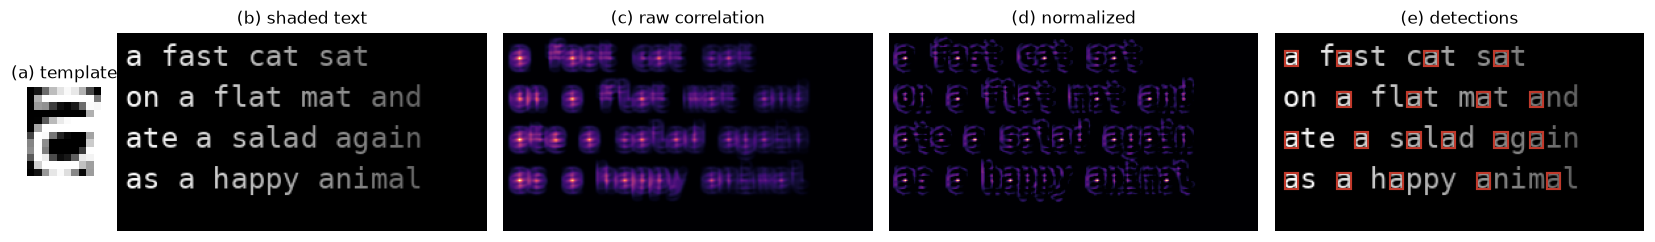

In [25]:
# Figure 15.12 — (a) template; (b) shaded text; (c) raw correlation (follows brightness, fails);
# (d) normalized correlation (clean peaks); (e) detections boxed on the image.
red = COLORS["red"]
imsh = lambda ax, im, t, **kw: (ax.imshow(im.squeeze().cpu(), **kw), ax.axis("off"), ax.set_title(t, fontsize=11))
fig, axs = plt.subplots(1, 5, figsize=(15, 3.8), gridspec_kw={"width_ratios": [0.6, 3, 3, 3, 3]})
imsh(axs[0], templ, "(a) template", cmap="gray")
imsh(axs[1], img, "(b) shaded text", cmap="gray")
imsh(axs[2], raw / raw.max(), "(c) raw correlation", cmap="magma", vmin=0, vmax=1)
imsh(axs[3], ncc.clamp(0, 1), "(d) normalized", cmap="magma", vmin=0, vmax=1)
imsh(axs[4], img, "(e) detections", cmap="gray")
for y, x in zip(py.tolist(), px.tolist()):
    axs[4].add_patch(Rectangle((x - tw / 2, y - th / 2), tw, th, fill=False, edgecolor=red, lw=1.4))
plt.tight_layout()
plt.show()

## 15.6 — System Identification

An LTI system is identified by its impulse response: feed in an impulse $\delta[n]$ and read out $h[n]$. A room's acoustics are an LTI system — a clap measures its impulse response, and any sound is that sound convolved with $h$.

**Figure 15.13 — an LTI system is fully described by its impulse response $h[n]$.**

> _Book §15.6, Figure 15.13 — drawn as a schematic._

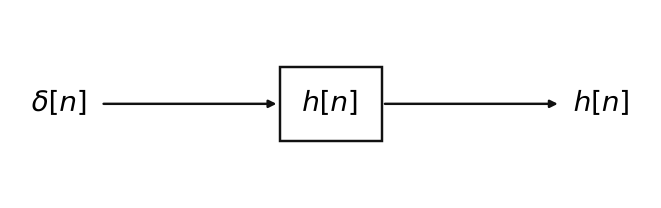

In [26]:
# Figure 15.13 — an LTI system is fully described by its impulse response. Feed the system an
# impulse δ[n]; what comes out, h[n], is the impulse response — and any input's output is that
# input convolved with h[n].
dark = COLORS["dark"]
fig, ax = plt.subplots(figsize=(7.5, 2.2)); ax.set(xlim=(0, 10), ylim=(0, 3)); ax.axis("off")
ax.add_patch(Rectangle((4.2, 0.9), 1.6, 1.2, fill=False, edgecolor=dark, lw=1.6))
ax.text(5.0, 1.5, r"$h[n]$", fontsize=18, ha="center", va="center")
ax.annotate("", xy=(4.2, 1.5), xytext=(1.4, 1.5), arrowprops=dict(arrowstyle="-|>", color=dark, lw=1.6))
ax.annotate("", xy=(8.6, 1.5), xytext=(5.8, 1.5), arrowprops=dict(arrowstyle="-|>", color=dark, lw=1.6))
ax.text(1.2, 1.5, r"$\delta[n]$", fontsize=18, ha="right", va="center")
ax.text(8.8, 1.5, r"$h[n]$", fontsize=18, ha="left", va="center")
plt.show()

**Figure 15.14 — room acoustics: sound reaches the microphone along many paths.**

> _Book §15.6, Figure 15.14 — this is a real photograph/sketch, referenced rather than reproduced (as in Chapter 20's cone-mosaic figure)._

**Figure 15.15 — measuring a room's acoustic impulse response.**

> _Book §15.6, Figure 15.15 — this is a real photograph/sketch, referenced rather than reproduced (as in Chapter 20's cone-mosaic figure)._

**Figure 15.16 — a voice signal convolved with a room impulse response.**

> _Book §15.6, Figure 15.16 — computed here._

In [27]:
# Figure 15.16 — a room is an LTI system: the sound you hear is the source convolved with the
# room's impulse response h (direct arrival + a few reflections + a decaying reverberant tail).
# We build a toy voice signal, a room h, and their convolution y = x * h — the reverberant signal.
import torch.nn.functional as F
n = torch.arange(520).float()
x = sum(torch.exp(-((n - c) / 24) ** 2) * torch.sin(2 * torch.pi * f * n) for c, f in [(90, 0.16), (250, 0.23), (400, 0.12)])
L = 170                                                       # room impulse response
h = torch.zeros(L); h[0] = 1.0
for d, a in [(20, 0.6), (38, 0.45), (60, 0.32), (88, 0.24)]: h[d] = a           # early reflections
h = h + torch.randn(L) * torch.exp(-torch.arange(L) / 42.0) * 0.14; h[0] = 1.0  # decaying reverberant tail
y = F.conv1d(x[None, None], h.flip(0)[None, None], padding=L - 1)[0, 0]         # y = x * h (full convolution)
print(f"voice {len(x)} samples, room h {L} taps -> reverberant y {len(y)} samples")

voice 520 samples, room h 170 taps -> reverberant y 689 samples


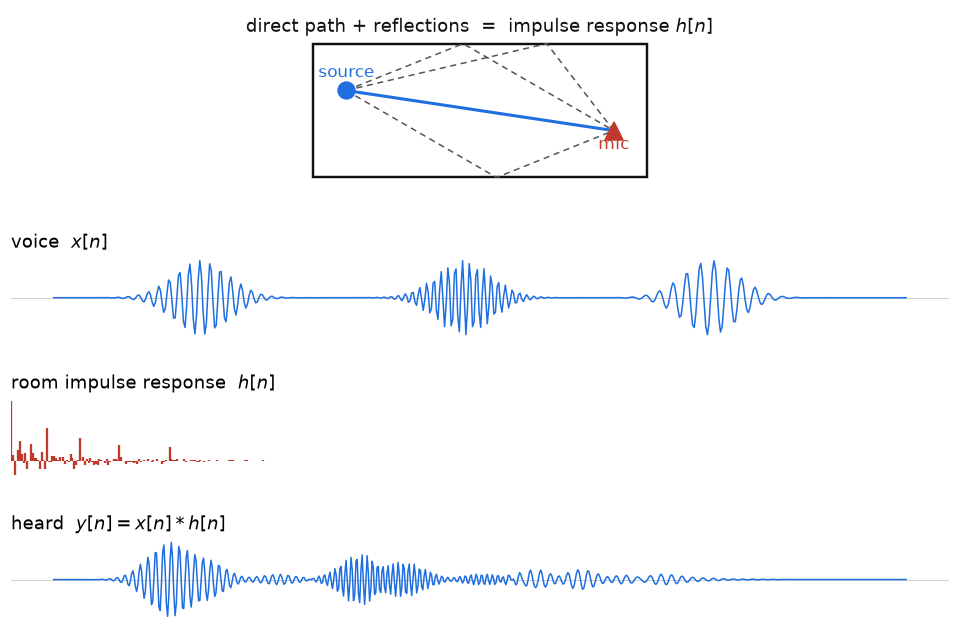

In [28]:
# Figure 15.16 — a room is an LTI system. Top: sound leaves the source and reaches the mic by a
# direct path plus wall reflections — that set of delayed arrivals IS the room's impulse response
# h[n]. Below: the clean voice x[n], the room's h[n], and what the mic hears, y[n] = x[n] * h[n].
dark, blue, red, gray = COLORS["dark"], COLORS["blue"], COLORS["red"], COLORS["gray"]
fig = plt.figure(figsize=(11, 7.2))
gsp = fig.add_gridspec(4, 1, height_ratios=[2.3, 1, 1, 1], hspace=0.55)
axr = fig.add_subplot(gsp[0])
# --- room schematic ---
axr.add_patch(Rectangle((0, 0), 10, 4, fill=False, edgecolor=dark, lw=1.6))
src, mic = (1.0, 2.6), (9.0, 1.4)
axr.plot(*src, "o", color=blue, ms=11, zorder=3); axr.text(src[0], src[1] + 0.4, "source", color=blue, ha="center", fontsize=11)
axr.plot(*mic, "^", color=red, ms=12, zorder=3); axr.text(mic[0], mic[1] - 0.55, "mic", color=red, ha="center", fontsize=11)
axr.plot([src[0], mic[0]], [src[1], mic[1]], color=blue, lw=2.0, zorder=2)                 # direct path
for bounce in [(4.5, 4.0), (5.5, 0.0), (7.0, 4.0)]:                                        # wall reflections
    axr.plot([src[0], bounce[0], mic[0]], [src[1], bounce[1], mic[1]], color=gray, lw=1.0, ls=(0, (4, 3)), zorder=1)
axr.text(5, 4.35, "direct path + reflections  =  impulse response $h[n]$", ha="center", fontsize=12, color=dark)
axr.set(xlim=(-0.4, 10.4), ylim=(-0.6, 5.0)); axr.set_aspect("equal"); axr.axis("off")
# --- three signals ---
ax_x, ax_h, ax_y = fig.add_subplot(gsp[1]), fig.add_subplot(gsp[2]), fig.add_subplot(gsp[3])
for ax, sig, lab in [(ax_x, x, r"voice  $x[n]$"), (ax_y, y, r"heard  $y[n]=x[n]*h[n]$")]:
    ax.plot(sig.cpu(), color=blue, lw=1.0); ax.set_title(lab, fontsize=12, loc="left")
    ax.axhline(0, color="0.8", lw=0.6, zorder=0); ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)
ax_h.stem(range(len(h)), h.cpu(), linefmt="-", markerfmt=" ", basefmt=" ")
for ln in ax_h.get_lines(): ln.set_color(red)
ax_h.collections[0].set_color(red)
ax_h.set_title(r"room impulse response  $h[n]$", fontsize=12, loc="left")
ax_h.set_xticks([]); ax_h.set_yticks([]); ax_h.set_xlim(0, len(x))
for s in ax_h.spines.values(): s.set_visible(False)
plt.show()

## 15.7 — Concluding remarks

Every operation in this chapter was one idea wearing different clothes. A **linear translation-invariant** system is a matrix multiply whose matrix is banded and Toeplitz (Figures 15.4, 15.6) — equivalently, a **convolution** with a single kernel (the impulse response) applied at every position (Figures 15.6–15.9). Blurring, shifting, averaging, edge detection, and template matching are all just different kernels. **Cross-correlation** is the same computation without the flip (Figure 15.11), and with local normalization it becomes a robust template detector (Figure 15.12). Because an LTI system is fully described by its impulse response, you can *identify* it by measuring that response — whether the system is a lens, a filter, or a room (Figures 15.13–15.16).